# Hierarchical analysis

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import country_converter as coco

## Loading countries data (population and GDP)

In [105]:
countries_df = pd.read_csv('./data/01_gdp_population.csv')
countries_df

,Country Name,Country Code,Population,GDP
0,Afghanistan,AFG,42647492,0.000000
1,Angola,AGO,37885849,2122.083690
2,Albania,ALB,2714617,10011.627986
3,Andorra,AND,81938,49303.673390
4,United Arab Emirates,ARE,10876981,49377.564338
...,...,...,...,...
188,Samoa,WSM,218019,4898.771408
189,"Yemen, Rep.",YEM,40583164,0.000000
190,South Africa,ZAF,64007187,6253.371582
191,Zambia,ZMB,21314956,1235.084665


Adding continent to each country for better analysis.

In [106]:
cc = coco.CountryConverter()

# Convertir códigos a continentes
countries_df['Continent'] = cc.pandas_convert(
    series=countries_df['Country Code'], 
    to='continent'
)

def ajustar_region(row):
    """
    Personaliza la clasificación continental para el análisis de TCF
    Separa América Latina de Norteamérica y usa nombres en español
    """
    if row['Continent'] == 'America' and row['Country Code'] not in ['USA', 'CAN']:
        return 'Latin America'
    elif row['Continent'] == 'America':
        return 'North America'
    elif row['Continent'] == 'Africa':
        return 'Africa'
    elif row['Continent'] == 'Oceania':
        return 'Oceania'
    elif row['Continent'] == 'Europe':
        return 'Europe'
    elif row['Continent'] == 'Asia':
        return 'Asia'
    else:
        return row['Continent']

countries_df['Continent'] = countries_df.apply(ajustar_region, axis=1)
countries_df['Continent'] = countries_df['Continent'].fillna('Otros')


print("\n Distribución de países por región:")
region_counts = countries_df['Continent'].value_counts()
display(region_counts)
countries_df['Total GDP'] = (countries_df['GDP'] * countries_df['Population'])
countries_df


 Distribución de países por región:


Continent
Africa           54
Asia             47
Europe           43
Latin America    33
Oceania          14
North America     2
Name: count, dtype: int64

,Country Name,Country Code,Population,GDP,Continent,Total GDP
0,Afghanistan,AFG,42647492,0.000000,Asia,0.000000e+00
1,Angola,AGO,37885849,2122.083690,Africa,8.039694e+10
2,Albania,ALB,2714617,10011.627986,Europe,2.717774e+10
3,Andorra,AND,81938,49303.673390,Europe,4.039844e+09
4,United Arab Emirates,ARE,10876981,49377.564338,Asia,5.370788e+11
...,...,...,...,...,...,...
188,Samoa,WSM,218019,4898.771408,Oceania,1.068025e+09
189,"Yemen, Rep.",YEM,40583164,0.000000,Asia,0.000000e+00
190,South Africa,ZAF,64007187,6253.371582,Africa,4.002607e+11
191,Zambia,ZMB,21314956,1235.084665,Africa,2.632578e+10


In [107]:
# droping countries with GDP of 0 since they were originally null values

countries_df = countries_df[countries_df['GDP'] > 0]

## Generation of other datasets

### **Company organizational structure dataset**

In [108]:
# Data directly reflects the TCF logistics-focused hierarchy (labels, parents, values)
org_data = {
    'labels': [
        'Terra Cotta Foods',
        'Operations', 'Supply Chain', 'Sales & Mkt', 'Finance & Admin',
        'Procurement', 'Logistics', 'Inventory Mgmt',
        'Processing', 'Quality Control', 'Facility Mgmt',
        'Regional Sales-LatAm', 'Regional Sales-Asia',
        'Accounting', 'HR & Legal', 'IT Support'
    ],
    'parents': [
        '',
        'Terra Cotta Foods', 'Terra Cotta Foods', 'Terra Cotta Foods', 'Terra Cotta Foods',
        'Supply Chain', 'Supply Chain', 'Supply Chain',
        'Operations', 'Operations', 'Operations',
        'Sales & Mkt', 'Sales & Mkt',
        'Finance & Admin', 'Finance & Admin', 'Finance & Admin'
    ],
    'values': [
        500,  # Total Company Value
        200,  # Operations
        150,  # Supply Chain
        80,   # Sales & Mkt
        70,   # Finance & Admin
        60,   # Procurement
        50,   # Logistics
        40,   # Inventory Mgmt
        75,   # Processing
        65,   # Quality Control
        60,   # Facility Mgmt
        45,   # Regional Sales-LatAm
        35,   # Regional Sales-Asia
        30,   # Accounting
        25,   # HR & Legal
        15    # IT Support
    ]
}

df_org = pd.DataFrame(org_data)
print("--- TCF Organizational Structure (df_org) Created ---")
print(f"Total workforce (calculated from root): {df_org[df_org['parents'] == '']['values'].sum()} employees.")
print(df_org[['labels', 'parents', 'values']].head())

--- TCF Organizational Structure (df_org) Created ---
Total workforce (calculated from root): 500 employees.
              labels            parents  values
0  Terra Cotta Foods                        500
1         Operations  Terra Cotta Foods     200
2       Supply Chain  Terra Cotta Foods     150
3        Sales & Mkt  Terra Cotta Foods      80
4    Finance & Admin  Terra Cotta Foods      70


In [109]:
df_org

,labels,parents,values
0,Terra Cotta Foods,,500
1,Operations,Terra Cotta Foods,200
2,Supply Chain,Terra Cotta Foods,150
3,Sales & Mkt,Terra Cotta Foods,80
4,Finance & Admin,Terra Cotta Foods,70
5,Procurement,Supply Chain,60
6,Logistics,Supply Chain,50
7,Inventory Mgmt,Supply Chain,40
8,Processing,Operations,75
9,Quality Control,Operations,65


### **Budget in company's departments dataset**

In [110]:
# Budget is in USD
budget_data = {
    'department': [
        'Operations', 'Operations',
        'Supply Chain', 'Supply Chain',
        'Sales & Mkt', 'Sales & Mkt',
        'Finance & Admin', 'Finance & Admin'
    ],
    'project': [
        'Efficiency Automation (Processing)', 'Energy Reduction Initiative',
        'LatAm Sourcing Partner Vetting', 'Asia Logistics Route Planning',
        'Digital B2B Platform Development', 'Regional Trade Show Attendance',
        'ERP System Update', 'Global Tax Compliance Review'
    ],
    'budget': [
        150000, 80000,
        120000, 100000,
        90000, 60000,
        140000, 70000
    ]
}

df_budget = pd.DataFrame(budget_data)

# Calculate total budget for verification
total_budget_usd = df_budget['budget'].sum()

print("\n--- TCF Project Budget (df_budget) Created ---")
print(f"Total project budget: ${total_budget_usd:,} USD.")
df_budget


--- TCF Project Budget (df_budget) Created ---
Total project budget: $810,000 USD.


,department,project,budget
0,Operations,Efficiency Automation (Processing),150000
1,Operations,Energy Reduction Initiative,80000
2,Supply Chain,LatAm Sourcing Partner Vetting,120000
3,Supply Chain,Asia Logistics Route Planning,100000
4,Sales & Mkt,Digital B2B Platform Development,90000
5,Sales & Mkt,Regional Trade Show Attendance,60000
6,Finance & Admin,ERP System Update,140000
7,Finance & Admin,Global Tax Compliance Review,70000


## **Situation**

Marco Antonelli es el Director General y fuerza impulsora de Terra Cotta Foods (TCF), una de las mayores distribuidoras de productos alimenticios premium y materias primas de Europa. El core de TCF es la adquisición, el procesamiento y la distribución de bienes, por lo que la eficiencia logística y el control de costes son vitales.
 
Marco está planificando una ambiciosa estrategia de expansión hacia América Latina y Asia para diversificar proveedores, asegurar cadenas de suministro y mitigar riesgos geopolíticos.

### **General goal:**

Determine the economic viability and the expansion potential of TCF supply chain in new markets.

### **Supply risks**

What is the correlation between the population (Labor force/Consumer basis) and the economic potential in the countries where Marco pretends to establish supply sources or factories?

### _**Solution**_

To solve this problem, we are going to use the countries dataset, which contains their GDP per capita and population. Based on that, we will find the economic potential by simply find the countries with the higher **Total GDP**, which is the multiplication of _`GDP per Capita * Population`_.
After that, we will find the asked correlation between population and total GDP (economic potential).

In [111]:
continents = ['Asia', 'Latin America', 'North America', 'Europe', 'Oceania', 'Africa']
continents_df = []
for continent in continents:
    df = countries_df[countries_df['Continent'] == continent]
    df = df.drop(columns=['Country Name', 'Country Code', 'Continent'])
    continents_df.append(df)

asia = continents_df[0]
latam = continents_df[1]
north_america = continents_df[2]
europe = continents_df[3]
oceania = continents_df[4]
africa = continents_df[5]

In [112]:
asia_correlation_df = asia.corr()
latam_correlation_df = latam.corr()
north_america_correlation_df = north_america.corr()
europe_correlation_df = europe.corr()
oceania_correlation_df = oceania.corr()
africa_correlation_df = africa.corr()

print(f'Correlation metrics in Asia\n{asia_correlation_df}\n')
print(f'Correlation metrics in Latin America\n{latam_correlation_df}\n')
print(f'Correlation metrics in North America\n{north_america_correlation_df}\n')
print(f'Correlation metrics in Europe\n{europe_correlation_df}\n')
print(f'Correlation metrics in Oceania\n{oceania_correlation_df}\n')
print(f'Correlation metrics in Africa\n{africa_correlation_df}\n')


Correlation metrics in Asia
            Population       GDP  Total GDP
Population    1.000000 -0.150648   0.795141
GDP          -0.150648  1.000000   0.000532
Total GDP     0.795141  0.000532   1.000000

Correlation metrics in Latin America
            Population       GDP  Total GDP
Population    1.000000 -0.137355   0.979873
GDP          -0.137355  1.000000  -0.062111
Total GDP     0.979873 -0.062111   1.000000

Correlation metrics in North America
            Population  GDP  Total GDP
Population         1.0  1.0        1.0
GDP                1.0  1.0        1.0
Total GDP          1.0  1.0        1.0

Correlation metrics in Europe
            Population       GDP  Total GDP
Population    1.000000 -0.090240   0.813655
GDP          -0.090240  1.000000   0.163691
Total GDP     0.813655  0.163691   1.000000

Correlation metrics in Oceania
            Population       GDP  Total GDP
Population    1.000000  0.784282   0.935815
GDP           0.784282  1.000000   0.856487
Total GDP     0.9

The metrics reveal a strong correlation between population and total GDP (the economic potential of the country), meaning that countries with higher population have a higher economic potential. On the other hand, the correlation between GDP per capita and population is weak, showing that a country's wealth per person does not necessarily relate to its population size. This, in terms of Marco's company, **the consumer base should be focused on lower-cost products**. These insights indicate, at first glance, that indeed **Latin America and Asia are the best options for an expansion strategy** but considering the previous fact.

As additional insights, entering in the African market with very low cost products may be beneficial for most of the population due to their low purchasing power. In addition, the total GDP indicates that it the continent has the potential to welcome the expansion infrastructure of the company. Another good prospect is Oceania, with a very attractive correlation not only in Total GDP but also in GDP per capita.

### **DISCLAIMER**

The last insight is academic only, mentioned just to illustate what we could get from the data, but we do not support the idea of expanding to Africa due to the poor labor conditions and human rights violations in many countries of the continent.

In [113]:
filtered_df = countries_df[countries_df['Continent'].isin(['Asia', 'Latin America'])]
filtered_df = filtered_df.sort_values(by=['Total GDP'], axis=0, ascending=False)
asia_df = filtered_df[filtered_df['Continent'] == 'Asia'].sort_values(by=['Total GDP'], ascending=False).head(10)
latam_df = filtered_df[filtered_df['Continent'] == 'Latin America'].sort_values(by=['Total GDP'], ascending=False).head(10)
top_df = pd.concat(objs=[asia_df, latam_df])
top_df

,Country Name,Country Code,Population,GDP,Continent,Total GDP
32,China,CHN,1408975000,13303.148154,Asia,1.874380e+13
86,Japan,JPN,123975371,32475.892499,Asia,4.026211e+12
77,India,IND,1450935791,2696.663900,Asia,3.912686e+12
76,Indonesia,IDN,283487931,4925.430488,Asia,1.396300e+12
176,Turkiye,TUR,85518661,15473.287264,Asia,1.323255e+12
148,Saudi Arabia,SAU,35300280,35057.225231,Asia,1.237530e+12
151,Singapore,SGP,6036860,90674.066633,Asia,5.473866e+11
82,Israel,ISR,9974400,54176.684438,Asia,5.403799e+11
4,United Arab Emirates,ARE,10876981,49377.564338,Asia,5.370788e+11
169,Thailand,THA,71668011,7345.135690,Asia,5.264113e+11


### **Creating the expansion strategy**

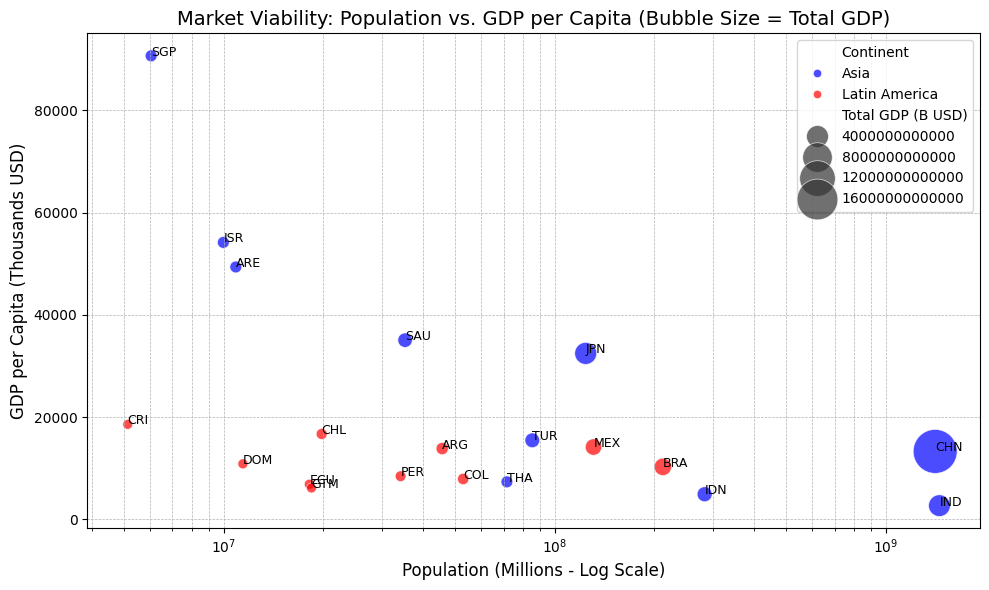

In [114]:
# Calculate the new variable: Total GDP (in Billions USD)
# (Population in M * GDP per Capita in k USD) -> Billion USD
filtered_df['Total GDP (B USD)'] = filtered_df['Population'] * filtered_df['GDP']
top_df['Total GDP (B USD)'] = top_df['Population'] * top_df['GDP']

# --- VISUALIZATION 1: External Viability (Scatter Plot) ---
plt.figure(figsize=(10, 6))
# Use log scale for Population to handle the wide range of values effectively
scatter = sns.scatterplot(
    data=top_df,
    x='Population',
    y='GDP',
    size='Total GDP (B USD)',
    hue='Continent',
    sizes=(50, 1000), # Define min/max size for markers
    alpha=0.7,
    palette={'Latin America': 'red', 'Asia': 'blue'}
)

# Add annotations (country codes)
for i, row in top_df.iterrows():
    plt.annotate(row['Country Code'], (row['Population'], row['GDP']), fontsize=9)

plt.title('Market Viability: Population vs. GDP per Capita (Bubble Size = Total GDP)', fontsize=14)
plt.xlabel('Population (Millions - Log Scale)', fontsize=12)
plt.ylabel('GDP per Capita (Thousands USD)', fontsize=12)
plt.xscale('log')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.show()

## **The supply distribution plan**

Now that we now which countries are more suitable to establish supply sources or factories and the economic situation of the people living in them (values gotten from the correlations), we have to find which countries are better based on the exportation of supplies considering their goods in the production of raw materials and their political context.

### **Dendogram of geographical distances**

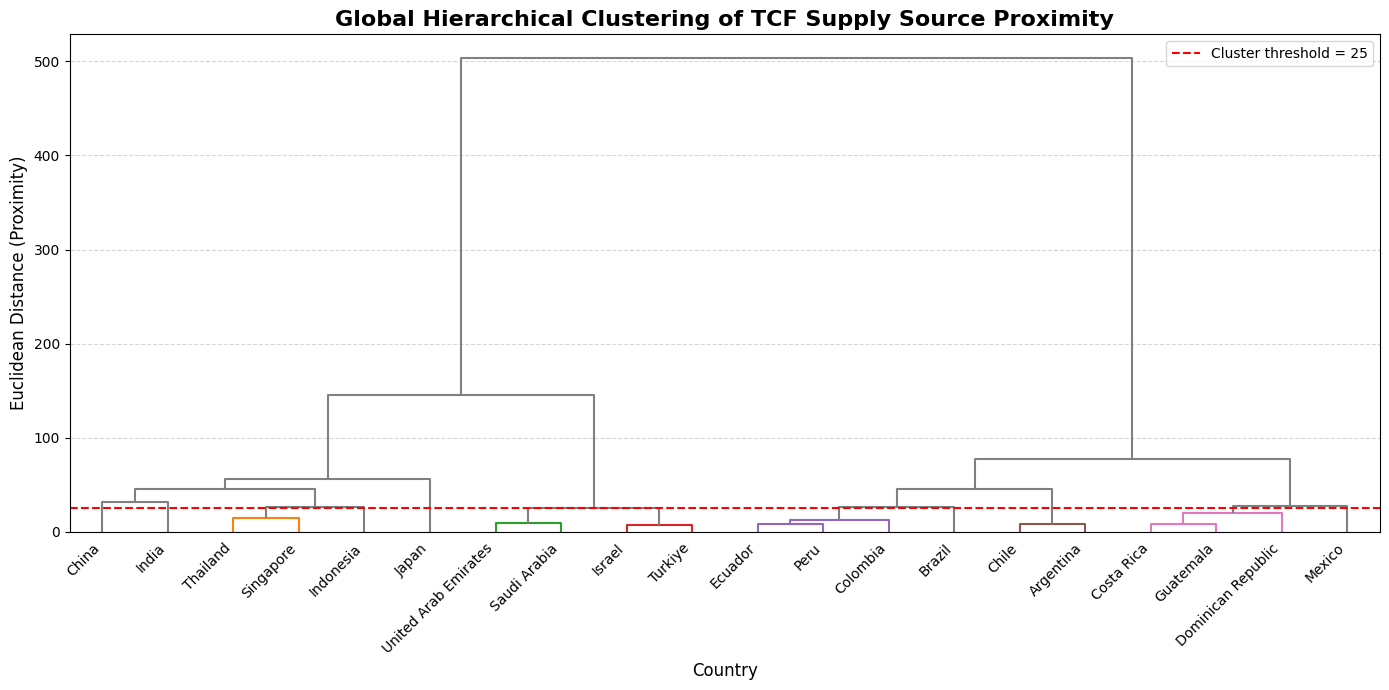

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

# --- 1. Geographical Data (Updated) ---
geo_data = {
    'Country Name': [
        'Brazil', 'Mexico', 'Colombia', 'Argentina', 'India', 'China', 'Indonesia', 'Japan',
        'Turkiye', 'Saudi Arabia', 'Singapore', 'Israel', 'United Arab Emirates', 
        'Thailand', 'Chile', 'Peru', 'Ecuador', 'Dominican Republic', 'Guatemala', 'Costa Rica'
    ],
    'Latitude': [
        -10, 23, 4, -34, 20, 35, -5, 36,
        39, 25, 1.3667, 31.5, 24, 15, -30, -10, -2, 19, 15.5, 10
    ],
    'Longitude': [
        -55, -102, -72, -64, 77, 105, 120, 138,
        35, 45, 103.8, 34.75, 54, 100, -71, -76, -77.5, -70.6667, -90.25, -84
    ],
    'Continent': [
        'Latam', 'Latam', 'Latam', 'Latam', 'Asia', 'Asia', 'Asia', 'Asia',
        'Asia', 'Asia', 'Asia', 'Asia', 'Asia', 'Asia', 'Latam', 'Latam', 'Latam', 'Latam', 'Latam', 'Latam'
    ]
}

df_geo = pd.DataFrame(geo_data)

# --- 2. Compute Distance Matrix and Linkage ---
X = df_geo[['Latitude', 'Longitude']].values
country_labels = df_geo['Country Name'].tolist()
distance_matrix = pdist(X, metric='euclidean')
linked = linkage(distance_matrix, method='ward')

# --- 3. Define Color Threshold and Cluster Count ---
# You can tweak `t` to change the number of visible color groups
threshold = 25  # distance threshold
clusters = fcluster(linked, threshold, criterion='distance')

# --- 4. Plot Enhanced Dendrogram ---
plt.figure(figsize=(14, 7))
dendrogram(
    linked,
    orientation='top',
    labels=country_labels,
    distance_sort='descending',
    show_leaf_counts=True,
    color_threshold=threshold,
    above_threshold_color='gray',
)

# --- 5. Enhancing the Plot ---
plt.title('Global Hierarchical Clustering of TCF Supply Source Proximity', fontsize=16, weight='bold')
plt.ylabel('Euclidean Distance (Proximity)', fontsize=12)
plt.xlabel('Country', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=1.5, label=f'Cluster threshold = {threshold}')
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()


### **Organizational structure visualizations**

In [116]:
# --- 2. Create the Sunburst Chart ---

fig = px.sunburst(
    df_org, 
    names='labels', 
    parents='parents', 
    values='values',
    title='TCF Organizational Structure: Labor Force Distribution',
    height=600,
    color='values',  # Color by employee count
    color_continuous_scale=px.colors.sequential.Viridis # Use a color scale
)

# Customize layout for better display
fig.update_layout(
    font=dict(size=12),
    title_x=0.5, # Center the title
)

# Showing the organizational structure
fig.show()

print("Sunburst chart that represents TCF's departments.")

Sunburst chart that represents TCF's departments.


Looking at the sunburst chart, the organizational structure of Marco's company shows a strong emphasis and in the supply chain and operations departments, which highlights the company's focus on logistics and cost control. This helps to create an expansion strategy based on the employee distribution by departments and subdepartments.

In [117]:
fig2 = px.treemap(
    df_budget, 
    path=['department', 'project'],  # Defines the hierarchy: Department -> Project
    values='budget',  # Defines the size of each block
    title='TCF Current Strategic Focus: Interactive Project Budget Allocation',
    color='budget',  # Color by budget to show the financing per department
    color_continuous_scale="peach"
)

# Plotting the interactive tree map
fig2.update_traces(textinfo="label+value", textfont_size=11)
fig2.update_layout(height=700, width=1000)
fig2.show()

### **Enhanced strategy plan**

Now, we are considering the rellocation of employees to other areas of the company to improve the expansion strategy.

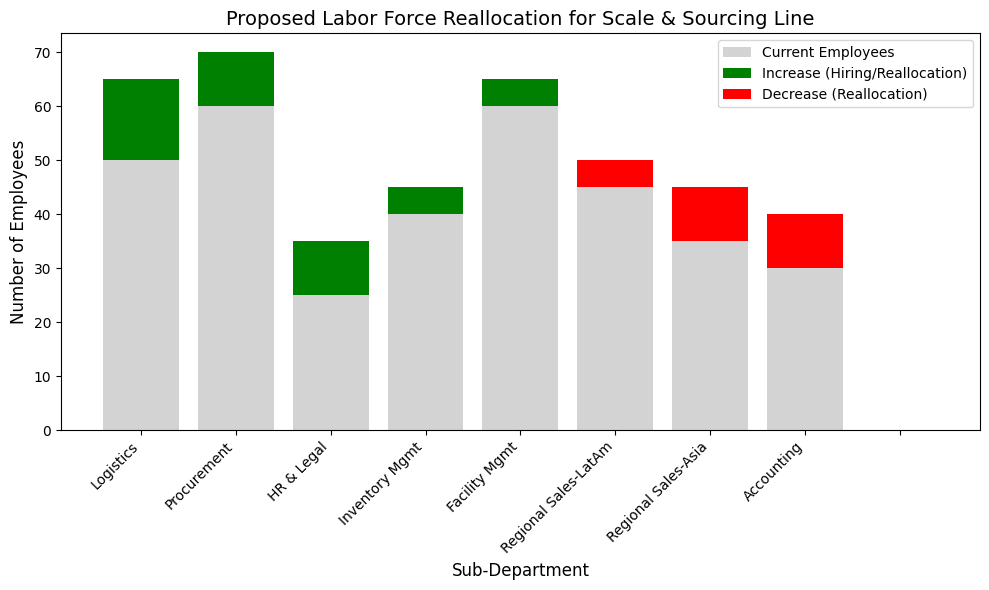

In [118]:
# Data created: Derived from the current TCF structure and the proposed changes above.
labor_reallocation_data = {
    'Sub-Department': ['Logistics', 'Procurement', 'HR & Legal', 'Inventory Mgmt', 'Facility Mgmt', 'Regional Sales-LatAm', 'Regional Sales-Asia', 'Accounting'],
    'Current Employees': [50, 60, 25, 40, 60, 45, 35, 30],
    'Adjustment': [15, 10, 10, 5, 5, -5, -10, -10] # Net shift is 45 - 25 = +20 (The total workforce increases by 20 with new hires for critical roles)
}
df_labor_change = pd.DataFrame(labor_reallocation_data)

# Create a column for the New Employee Count
df_labor_change['New Employees'] = df_labor_change['Current Employees'] + df_labor_change['Adjustment']

# Determine the change type for coloring
df_labor_change['Change Type'] = df_labor_change['Adjustment'].apply(lambda x: 'Increase' if x > 0 else 'Decrease')

# --- Create the Comparative Bar Chart ---
plt.figure(figsize=(10, 6))

# Use the current workforce as the base bar
plt.bar(df_labor_change['Sub-Department'], df_labor_change['Current Employees'], label='Current Employees', color='lightgrey')

# Use a second bar to show the adjustment (increase/decrease)
# The bottom of the adjustment bar is the current employee count for increases
# The top of the adjustment bar is the new employee count for decreases
for index, row in df_labor_change.iterrows():
    if row['Adjustment'] > 0:
        plt.bar(row['Sub-Department'], row['Adjustment'], bottom=row['Current Employees'], color='green', label='_nolegend_')
    else:
        plt.bar(row['Sub-Department'], row['Adjustment'], bottom=row['Current Employees'] - row['Adjustment'], color='red', label='_nolegend_')

# Re-adding the legend handles (simplifying legend for clarity)
plt.bar([''], [0], color='green', label='Increase (Hiring/Reallocation)')
plt.bar([''], [0], color='red', label='Decrease (Reallocation)')

plt.title('Proposed Labor Force Reallocation for Scale & Sourcing Line', fontsize=14)
plt.xlabel('Sub-Department', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

And we also consider budget adjustments to put the expansion project as priority.

In [119]:
# Data for the Sankey flow (Source, Target, Value)
sankey_data = {
    'Source': [
        'Energy Reduction Initiative (80K)', 'Regional Trade Show (60K)', 'Digital B2B Platform (90K)',
        # Savings Pool flows to the new investments
        'Savings Pool', 'Savings Pool', 'Savings Pool'
    ],
    'Target': [
        'Savings Pool', 'Savings Pool', 'Savings Pool',
        'LatAm Sourcing (+50K)', 'Asia Logistics (+40K)', 'Global Tax Comp. (+30K)'
    ],
    'Value': [
        50000, 40000, 30000,  # Funds moved to the pool
        50000, 40000, 30000   # Funds moved from the pool
    ]
}
df_sankey = pd.DataFrame(sankey_data)

# --- Create the Sankey Diagram ---
# Generate a list of all unique nodes for the indices
all_nodes = list(pd.concat([df_sankey['Source'], df_sankey['Target']]).unique())
node_dict = {node: i for i, node in enumerate(all_nodes)}

# Map the source and target strings to their integer indices
df_sankey['Source_Index'] = df_sankey['Source'].map(node_dict)
df_sankey['Target_Index'] = df_sankey['Target'].map(node_dict)

# Create the Sankey plot
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=all_nodes,
        color='blue'
    ),
    link=dict(
        source=df_sankey['Source_Index'],
        target=df_sankey['Target_Index'],
        value=df_sankey['Value'],
        label=df_sankey['Source'] + ' -> ' + df_sankey['Target'], # Add a label to the flow for clarity
        hovertemplate='Flow from %{source.label}<br>to %{target.label}<br>Value: $%{value:,.0f}<extra></extra>'
    )
)])

fig.update_layout(
    title_text="Proposed Budget Reallocation (Net Zero Change)", 
    font_size=10,
    height=600
)

fig.show()

In [120]:
"""v2_df = pd.DataFrame(
    {'Job': ['Design', 'Product Management', 'Analytics',
               'Enterprise', 'SMB', 'Partnerships',
               'HR', 'Finance', 'Legal', 'IT',
               'Backend-Team1', 'Backend-Team2', 'Frontend-Team1', 'Frontend-Team2',
               'Mobile-iOS', 'Mobile-Android', 'DevOps-Cloud', 'DevOps-Security',
               'UI/UX', 'Research', 'PM-Core', 'PM-Growth',
               'Data-Science', 'BI'],
     'Subdepartment':['Backend', 'Backend', 'Frontend', 'Frontend',
                'Mobile', 'Mobile', 'DevOps', 'DevOps',
                'Design', 'Design', 'Product Management', 'Product Management',
                'Analytics', 'Analytics'],
     'Department': ['Engineering', 'Engineering', 'Engineering', 'Engineering',
                'Product', 'Product', 'Product',
                'Sales', 'Sales', 'Sales',
                'Operations', 'Operations', 'Operations', 'Operations',],
     'Employees': [60, 50, 40, 30,
               30, 25, 25,
               50, 40, 30,
               40, 35, 25, 20,
               30, 30, 25, 25,
               20, 20, 15, 15,
               15, 15, 12, 13,
               13, 12]
                      }
                     )

v2_df"""

"v2_df = pd.DataFrame(\n    {'Job': ['Design', 'Product Management', 'Analytics',\n               'Enterprise', 'SMB', 'Partnerships',\n               'HR', 'Finance', 'Legal', 'IT',\n               'Backend-Team1', 'Backend-Team2', 'Frontend-Team1', 'Frontend-Team2',\n               'Mobile-iOS', 'Mobile-Android', 'DevOps-Cloud', 'DevOps-Security',\n               'UI/UX', 'Research', 'PM-Core', 'PM-Growth',\n               'Data-Science', 'BI'],\n     'Subdepartment':['Backend', 'Backend', 'Frontend', 'Frontend',\n                'Mobile', 'Mobile', 'DevOps', 'DevOps',\n                'Design', 'Design', 'Product Management', 'Product Management',\n                'Analytics', 'Analytics'],\n     'Department': ['Engineering', 'Engineering', 'Engineering', 'Engineering',\n                'Product', 'Product', 'Product',\n                'Sales', 'Sales', 'Sales',\n                'Operations', 'Operations', 'Operations', 'Operations',],\n     'Employees': [60, 50, 40, 30,\n          

Transforming dataframes into JSON format to use them the website.

In [121]:
df_org.to_json(path_or_buf='./data/organization.json', index= False, orient='records')
df_budget.to_json(path_or_buf='./data/budget.json', index= False, orient='records')
countries_df.to_json(path_or_buf='./data/countries.json', index= False, orient='records')
filtered_df.to_json(path_or_buf='./data/asia_latam.json', index= False, orient='records')
top_df.to_json(path_or_buf='./data/top10_asia_latam.json', index= False, orient='records')
df_labor_change.to_json(path_or_buf='./data/job_rellocation.json', index= False, orient='records')
df_sankey.to_json(path_or_buf='./data/budget_rellocation.json', index= False, orient='records')